# Week 3 — Monday: Geometric Transformations

## Learning Objectives
- Understand affine and perspective transformations
- Learn homography matrix concepts
- Implement warpPerspective for real-world applications
- Build a document scanner mini-demo

## Key Concepts
1. **Affine Transformations**: 2×3 matrix, preserves parallel lines
2. **Perspective Transformations**: 3×3 matrix, homography
3. **warpAffine & warpPerspective**: OpenCV image warping
4. **Document Scanner Pipeline**: Edge detection → corner detection → perspective warp

## Section 1: Theory — Geometric Transformations

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Display configuration
plt.rcParams['figure.figsize'] = (12, 6)

### 1.1 Affine Transformation Matrix

An affine transformation is represented by a 2×3 matrix:
```
[a₀ a₁ b₀]
[a₂ a₃ b₁]
```

The transformation maps (x, y) → (x', y') as:
```
x' = a₀·x + a₁·y + b₀
y' = a₂·x + a₃·y + b₁
```

**Key Property**: Parallel lines remain parallel after transformation.

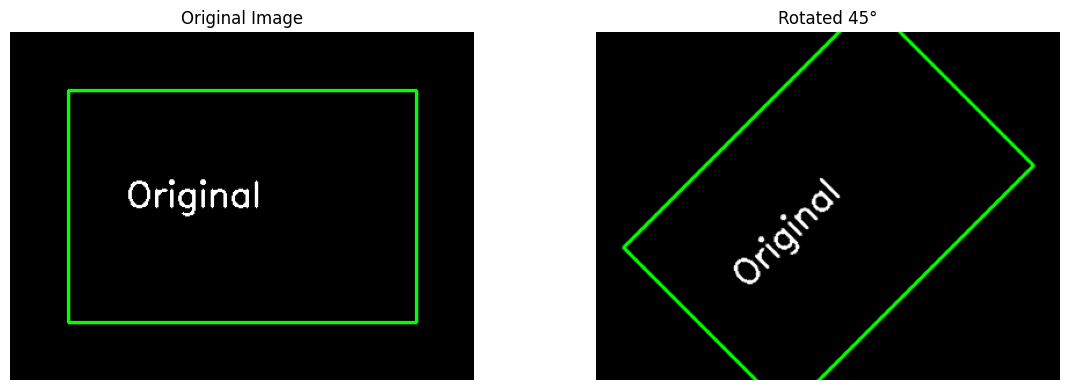

Rotation Matrix (2×3):
[[  0.70710678   0.70710678 -47.48737342]
 [ -0.70710678   0.70710678 185.35533906]]


In [2]:
# Example 1: Rotation using affine transformation
def create_rotation_matrix(angle_deg, center=None, scale=1.0):
    """
    Create a 2D rotation matrix.
    
    Args:
        angle_deg: Rotation angle in degrees (counter-clockwise)
        center: Center of rotation (cx, cy). If None, uses image center
        scale: Scale factor
    
    Returns:
        2×3 affine transformation matrix
    """
    angle_rad = np.radians(angle_deg)
    cos_a = np.cos(angle_rad)
    sin_a = np.sin(angle_rad)
    
    # Rotation matrix
    rotation_matrix = np.array([
        [cos_a, -sin_a, 0],
        [sin_a, cos_a, 0]
    ], dtype=np.float32) * scale
    
    return rotation_matrix

# Create a simple test image
img = np.zeros((300, 400, 3), dtype=np.uint8)
cv2.rectangle(img, (50, 50), (350, 250), (0, 255, 0), 2)
cv2.putText(img, 'Original', (100, 150), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

# Rotate 45 degrees around center
h, w = img.shape[:2]
center = (w // 2, h // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, angle=45, scale=1.0)
rotated = cv2.warpAffine(img, rotation_matrix, (w, h))

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
axes[1].set_title('Rotated 45°')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print("Rotation Matrix (2×3):")
print(rotation_matrix)

### 1.2 Perspective Transformation (Homography)

A perspective transformation is represented by a 3×3 matrix (homography):
```
[h₀ h₁ h₂]
[h₃ h₄ h₅]
[h₆ h₇ h₈]
```

Maps points in homogeneous coordinates:
```
[x']
[y'] = H · [x]
[w']      [y]
           [1]
```

Actual coordinates: x = x'/w', y = y'/w'

**Key Property**: Parallel lines may NOT remain parallel (can converge to a vanishing point).

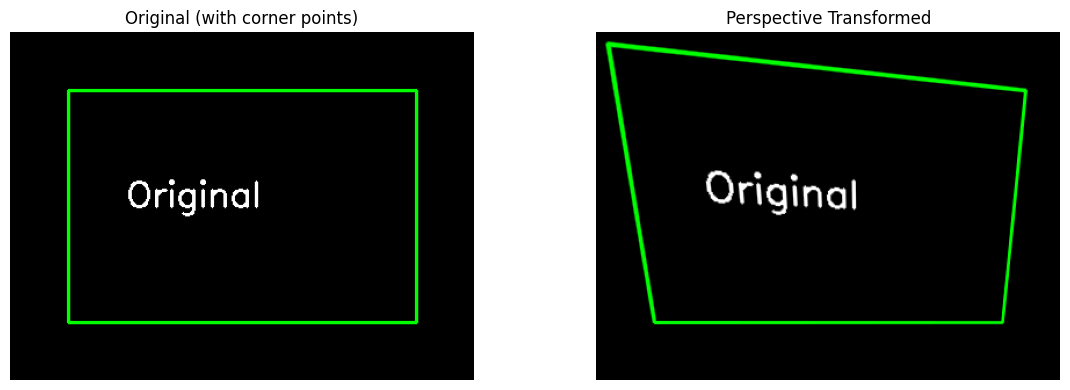

Perspective (Homography) Matrix (3×3):
[[ 1.58394161e+00  2.77372263e-01 -8.21167883e+01]
 [ 1.82481752e-01  1.60583942e+00 -7.84671533e+01]
 [ 7.29927007e-04  1.16788321e-03  1.00000000e+00]]


In [3]:
# Example 2: Perspective transformation
# Define source and destination points
src_pts = np.float32([
    [50, 50],      # top-left
    [350, 50],     # top-right
    [50, 250],     # bottom-left
    [350, 250]     # bottom-right
])

dst_pts = np.float32([
    [10, 10],      # top-left (moved inward)
    [370, 50],     # top-right
    [50, 250],     # bottom-left
    [350, 250]     # bottom-right
])

# Get perspective transformation matrix
perspective_matrix = cv2.getPerspectiveTransform(src_pts, dst_pts)
perspective_warped = cv2.warpPerspective(img, perspective_matrix, (w, h))

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original (with corner points)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(perspective_warped, cv2.COLOR_BGR2RGB))
axes[1].set_title('Perspective Transformed')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print("Perspective (Homography) Matrix (3×3):")
print(perspective_matrix)

## Section 2: Practical Applications

### 2.1 Image Shearing

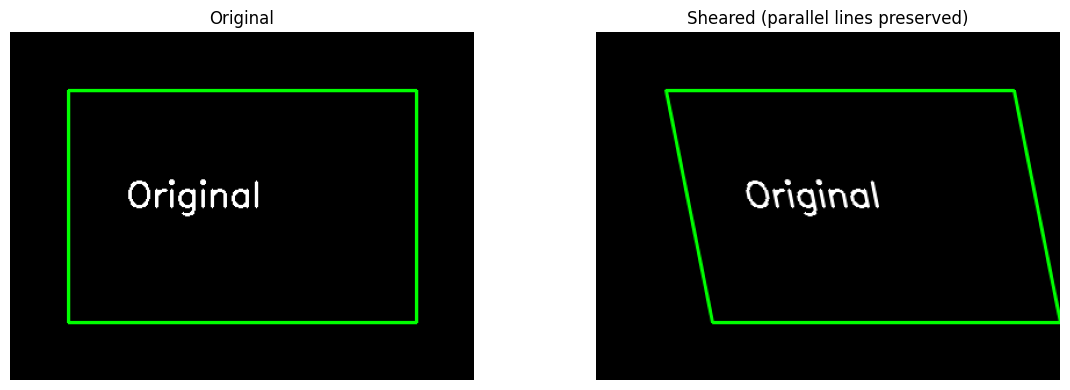

In [4]:
# Shear transformation
shear_amount = 0.2
shear_matrix = np.float32([
    [1, shear_amount, 0],
    [0, 1, 0]
])

sheared = cv2.warpAffine(img, shear_matrix, (w, h))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(sheared, cv2.COLOR_BGR2RGB))
axes[1].set_title('Sheared (parallel lines preserved)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### 2.2 Image Scaling & Translation

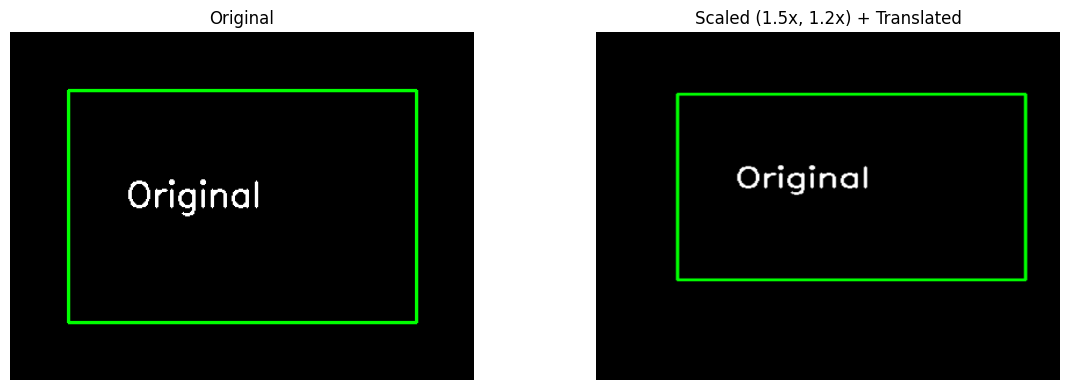

In [5]:
# Scaling and translation combined
scale_x, scale_y = 1.5, 1.2
tx, ty = 30, 20  # translation

scale_translate_matrix = np.float32([
    [scale_x, 0, tx],
    [0, scale_y, ty]
])

scaled_translated = cv2.warpAffine(img, scale_translate_matrix, (int(w*1.5), int(h*1.5)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(scaled_translated, cv2.COLOR_BGR2RGB))
axes[1].set_title('Scaled (1.5x, 1.2x) + Translated')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Section 3: Document Scanner Demo

### 3.1 Detect Document Corners

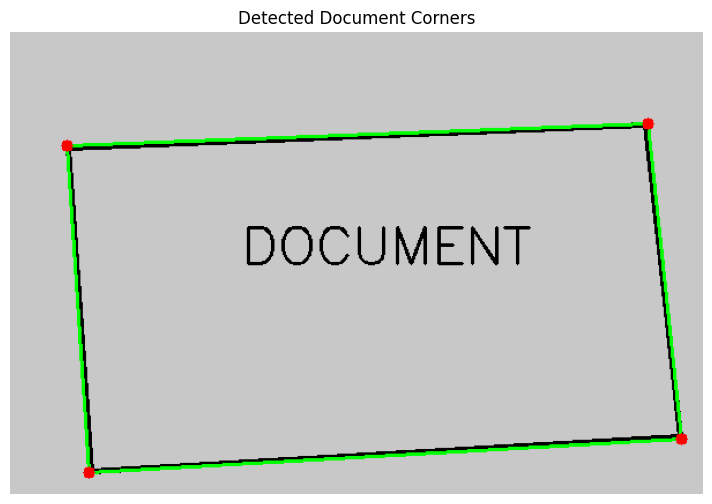

Detected corners shape: (4, 1, 2)
Corner coordinates:
[[[552  79]]

 [[ 49  98]]

 [[ 68 381]]

 [[581 352]]]


In [6]:
def detect_document_corners(image, visualize=True):
    """
    Detect corners of a document in an image.
    
    Steps:
    1. Convert to grayscale
    2. Apply Gaussian blur
    3. Canny edge detection
    4. Find contours
    5. Sort and filter contours by area
    6. Extract corner points from largest quadrilateral
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 100, 200)
    
    # Find contours
    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    
    # Find largest quadrilateral contour
    largest_contour = None
    largest_area = 0
    
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > largest_area:
            # Approximate contour to polygon
            peri = cv2.arcLength(contour, True)
            approx = cv2.approxPolyDP(contour, 0.02 * peri, True)
            
            # We want a quadrilateral
            if len(approx) == 4:
                largest_area = area
                largest_contour = approx
    
    if visualize and largest_contour is not None:
        viz_img = image.copy()
        cv2.drawContours(viz_img, [largest_contour], 0, (0, 255, 0), 2)
        for point in largest_contour:
            cv2.circle(viz_img, tuple(point[0]), 5, (0, 0, 255), -1)
        
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(viz_img, cv2.COLOR_BGR2RGB))
        plt.title('Detected Document Corners')
        plt.axis('off')
        plt.show()
    
    return largest_contour

# Create a document-like image for demo
doc_img = np.ones((400, 600, 3), dtype=np.uint8) * 200
# Draw a rotated rectangle to simulate a document
pts = np.array([[50, 100], [550, 80], [580, 350], [70, 380]], dtype=np.int32)
cv2.polylines(doc_img, [pts], True, (0, 0, 0), 3)
cv2.putText(doc_img, 'DOCUMENT', (200, 200), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 2)

corners = detect_document_corners(doc_img)
print(f"Detected corners shape: {corners.shape}")
if corners is not None:
    print(f"Corner coordinates:\n{corners}")

### 3.2 Apply Perspective Correction

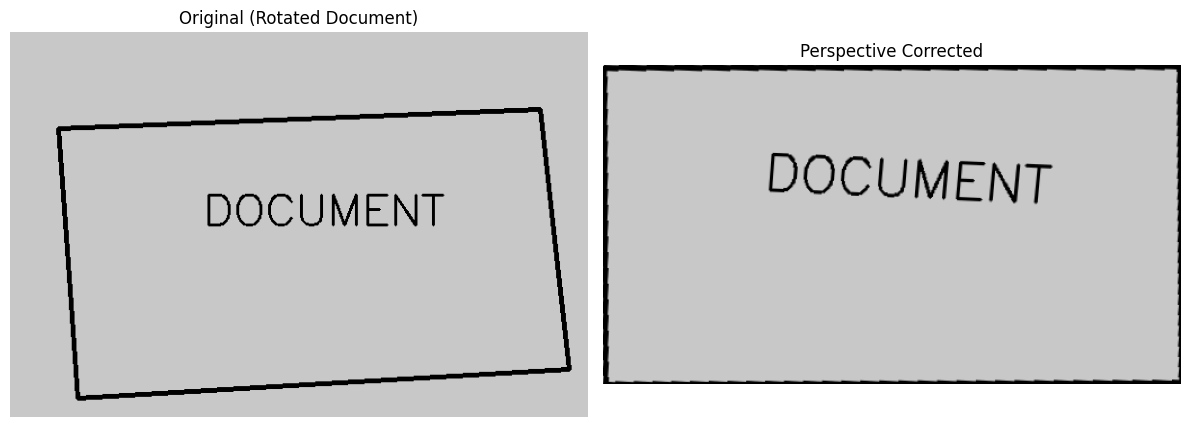

Original shape: (400, 600, 3)
Corrected shape: (283, 513, 3)


In [7]:
def order_corner_points(corners):
    """
    Order corner points: [top-left, top-right, bottom-right, bottom-left]
    """
    corners = corners.reshape(4, 2)
    
    # Sort by x-coordinate
    corners = corners[np.argsort(corners[:, 0])]
    
    # Split into left and right
    left = corners[:2]
    right = corners[2:]
    
    # Sort each side by y-coordinate
    left = left[np.argsort(left[:, 1])]
    right = right[np.argsort(right[:, 1])]
    
    # Reorder to: [top-left, top-right, bottom-right, bottom-left]
    ordered = np.vstack([left[0], right[0], right[1], left[1]])
    return ordered.astype(np.float32)

def perspective_correct_document(image, corners):
    """
    Apply perspective correction to a document.
    """
    if corners is None:
        return image
    
    # Order corners properly
    src_pts = order_corner_points(corners)
    
    # Define destination points (rectangular)
    h, w = image.shape[:2]
    # Calculate width and height of the document
    width = max(
        np.linalg.norm(src_pts[1] - src_pts[0]),
        np.linalg.norm(src_pts[2] - src_pts[3])
    )
    height = max(
        np.linalg.norm(src_pts[3] - src_pts[0]),
        np.linalg.norm(src_pts[2] - src_pts[1])
    )
    
    dst_pts = np.float32([
        [0, 0],
        [width, 0],
        [width, height],
        [0, height]
    ])
    
    # Get perspective transform and apply
    M = cv2.getPerspectiveTransform(src_pts, dst_pts)
    warped = cv2.warpPerspective(image, M, (int(width), int(height)))
    
    return warped

# Apply perspective correction
corrected = perspective_correct_document(doc_img, corners)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(doc_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original (Rotated Document)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
axes[1].set_title('Perspective Corrected')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f"Original shape: {doc_img.shape}")
print(f"Corrected shape: {corrected.shape}")

## Section 4: Key Takeaways

1. **Affine Transformations (2×3 matrix)**:
   - Rotation, scaling, translation, shearing
   - Parallel lines remain parallel
   - Uses `cv2.warpAffine()`

2. **Perspective Transformations (3×3 Homography)**:
   - Non-parallel lines may converge
   - Requires 4 point correspondences
   - Uses `cv2.warpPerspective()`

3. **Document Scanner Pipeline**:
   - Edge detection → Contour finding → Corner extraction → Perspective correction
   - Useful for mobile document scanning, OCR preprocessing

4. **Real-world Applications**:
   - Document scanning
   - Image stitching
   - Viewpoint correction
   - Augmented reality

## Exercises

1. Create a rotation matrix by hand (without `cv2.getRotationMatrix2D`) and apply it.
2. Implement a 90° rotation using affine transformation.
3. Create a perspective distortion that simulates viewing a document from an angle.
4. Test your document scanner on an image with curved edges.